# introduction

[介绍](https://www.kaggle.com/code/tomforbes/optiver-trading-at-the-close-introduction#Trading-At-The-Close)

预测股票收盘价

最后10分钟，允许委托，不支持撤单，最后一刻统一价格撮合（按照成交量最大），产生收盘价。

**近端价、远端价、参考**

15:50:00开始收盘竞价，每隔10秒收集数据

0-300秒：纳斯达克不公布近端和远端价格

300-600: 300开始实时发布近端/远端价格

600：价格确定

- 远端价：一些人等到第30秒发起订单，**就是这一秒**，远端价就是只看这几个人可以成交的价格。如果Nan就是得不到成交价格
- 近端价：把这些人的订单和白天剩余订单全在一起，计算出的成交价格就是 近端价。
近端价相比远端价更加稳定。
- 参考价：近端价和远端价都可能会出现很离谱的价格，参考价是市场设定的保护范围

这三个价格最终会收敛到一起


**imbalance失衡**：

比如苹果股票，400秒时候。

按照参考价

场景1：买方多。
- `imbalance_size` = 100万 表示按照参考价，不能成交的订单额。即买的人多
- `imbalance_buy_sell_flag` = 1
- `matched_size` = 300万， 按照参考价，此时能够成交的订单额

场景2：正好平衡
- `imbalance_size` = 0
- `imbalance_buy_sell_flag` = 0
- `matched_size` = 400万， 按照参考价，此时能够成交的订单额



wap是加权平均价格，所以总是介于ask和bid之间

In [11]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
import re
from contextlib import contextmanager
import time
import os

gc.enable()
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['figure.figsize'] = (8,6) 
plt.rcParams['figure.dpi'] = 100

sns.set_theme(style="whitegrid", palette="Set1")


In [3]:
data = pd.read_csv('data/train.csv')

In [48]:
data.columns

Index(['stock_id', 'date_id', 'seconds_in_bucket', 'imbalance_size',
       'imbalance_buy_sell_flag', 'reference_price', 'matched_size',
       'far_price', 'near_price', 'bid_price', 'bid_size', 'ask_price',
       'ask_size', 'wap', 'target', 'time_id', 'row_id'],
      dtype='object')

In [35]:
def info_data(df):
    print(f'shape {df.shape}')
    n_stock =len(df['stock_id'].value_counts())
    print(f'stocks {n_stock}')
    n_days = len(df['date_id'].value_counts())
    print(f'days {n_days}')

In [36]:
info_data(data)

shape (5237980, 17)
stocks 200
days 481


In [83]:
def plot_stock(df, stock, date):

    fig, axes = plt.subplots(1,3, figsize=(15,5))
    plot_df = df[(df['stock_id'] ==stock) & (df['date_id'] == date) ]
    melted_data = plot_df.melt(
        id_vars = 'seconds_in_bucket',
        value_vars = ['far_price', 'near_price', 'reference_price','wap'],
        value_name = 'price_value',
        var_name = 'price_type'
    )
    # 左图：近端、远端价、参考价 收敛
    sns.lineplot(data=melted_data, x='seconds_in_bucket', y='price_value', hue='price_type', ax=axes[0])
    axes[0].set_title(f"Auction Prices (Stock {stock}, Day {date})")
    
    melted_data = plot_df.melt(
        id_vars = 'seconds_in_bucket',
        value_vars = ['bid_price', 'ask_price', 'wap'],
        var_name = 'Price_Type',
        value_name = 'Price_Value'
    )
    # 中图：订单本最优买卖价格
    sns.lineplot(data=melted_data, x='seconds_in_bucket', y='Price_Value', hue='Price_Type', ax=axes[1])
    axes[1].set_title(f"Market Liquidity (Stock {stock}, Day {date})")


    # 右图：imbalance
    axes[2].fill_between(plot_df['seconds_in_bucket'], plot_df['matched_size'], color='gray', alpha=0.3, label='Matched Size')
    axes[2].set_ylabel('Matched size')
    tax = axes[2].twinx()
    plot_df['signed_imb'] = plot_df['imbalance_size'] * plot_df['imbalance_buy_sell_flag']
    sns.lineplot(data=plot_df, x='seconds_in_bucket', y='signed_imb', ax=tax, label='Signed Imbalance')
    tax.set_ylabel('Signed Imbalance (Buy > 0, Sell < 0)', color='purple')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[2].set_title(f"Imbalance Dynamics (Stock {stock}, Day {date})")

    plt.tight_layout()
    plt.show()

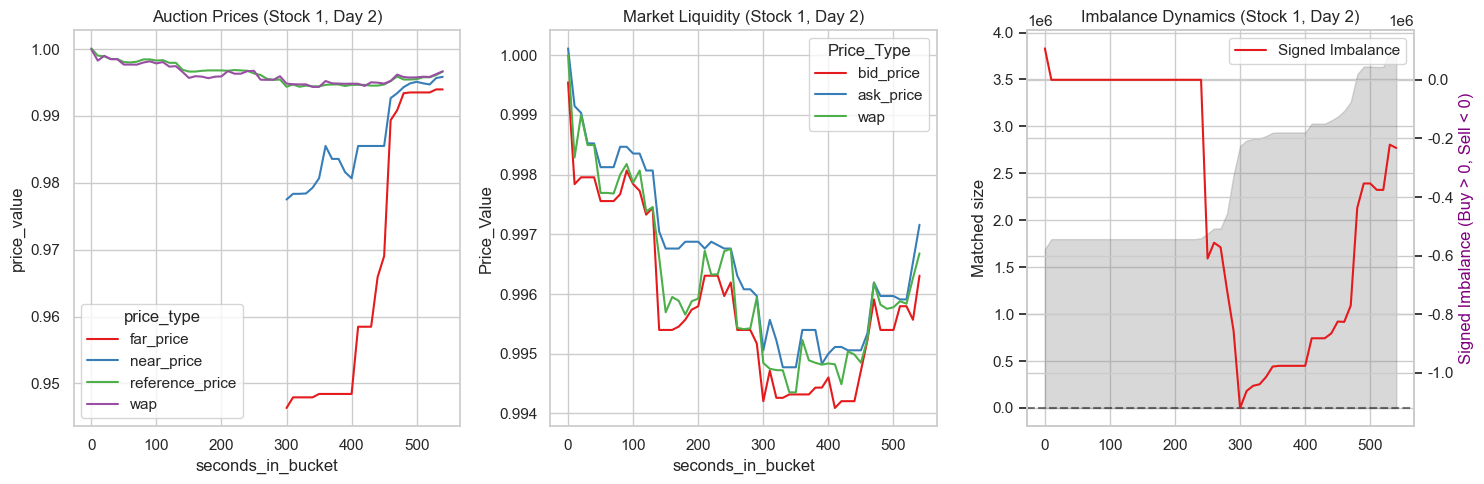

In [84]:
plot_stock(data, stock=1, date=2)

## metrics

MAE


## 字段说明
- stock_id: 股票的唯一标识。
- date_id: 日期的唯一标识（按天递增）。
- seconds_in_bucket: 当前竞价时段内经过的秒数（从 0 开始，每 10 秒一行，最高到 540）。
- time_id / row_id: 唯一行标识。

竞价数据：反应供需
- imbalance_size: 以美元计量的未匹配金额。
- imbalance_buy_sell_flag: 失衡方向。1 代表买方失衡（买单多），-1 代表卖方失衡，0 代表平衡。
- matched_size: 当前参考价下可以匹配成交的金额（美元）。
- reference_price: 参考价格。它是使配对股份最大化、不平衡最小化的价格，通常被限制在最佳买卖价之间。
- far_price: 远端价格。仅基于竞价订单计算的模拟成交价（不含连续交易时段的订单）。
- near_price: 近端价格。结合了竞价订单和连续交易订单后的模拟成交价。

订单数据
- bid_price / ask_price: 订单簿中最优买入/卖出价（买一/卖一）。
- bid_size / ask_size: 最优买入/卖出位的美元金额。
- wap:成交量加权平均价（Weighted Average Price）
$$
\frac{BidPrice * BidSize + AskPrice * AskSize}{BidSize + AskSize}
$$

- target
股票未来 60 秒的 WAP 涨幅，

In [17]:
data.describe()

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id
count,5.237980e+06,5.237980e+06,5.237980e+06,5.237760e+06,5.237980e+06,5.237760e+06,5.237760e+06,2.343638e+06,2.380800e+06,5.237760e+06,5.237980e+06,5.237760e+06,5.237980e+06,5.237760e+06,5.237892e+06,5.237980e+06
mean,9.928856e+01,2.415100e+02,2.700000e+02,5.715293e+06,-1.189619e-02,9.999955e-01,4.510025e+07,1.001713e+00,9.996601e-01,9.997263e-01,5.181359e+04,1.000264e+00,5.357568e+04,9.999920e-01,-4.756125e-02,1.331005e+04
std,5.787176e+01,1.385319e+02,1.587451e+02,2.051591e+07,8.853374e-01,2.532497e-03,1.398413e+08,7.214705e-01,1.216920e-02,2.499345e-03,1.114214e+05,2.510042e-03,1.293554e+05,2.497509e-03,9.452860e+00,7.619271e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,9.352850e-01,4.316610e+03,7.700000e-05,7.869880e-01,9.349150e-01,0.000000e+00,9.398270e-01,0.000000e+00,9.380080e-01,-3.852898e+02,0.000000e+00
25%,4.900000e+01,1.220000e+02,1.300000e+02,8.453415e+04,-1.000000e+00,9.987630e-01,5.279575e+06,9.963320e-01,9.971000e-01,9.985290e-01,7.374720e+03,9.990290e-01,7.823700e+03,9.987810e-01,-4.559755e+00,6.729000e+03
50%,9.900000e+01,2.420000e+02,2.700000e+02,1.113604e+06,0.000000e+00,9.999670e-01,1.288264e+07,9.998830e-01,9.998890e-01,9.997280e-01,2.196900e+04,1.000207e+00,2.301792e+04,9.999970e-01,-6.020069e-02,1.334500e+04
75%,1.490000e+02,3.610000e+02,4.100000e+02,4.190951e+06,1.000000e+00,1.001174e+00,3.270013e+07,1.003318e+00,1.002590e+00,1.000905e+00,5.583168e+04,1.001414e+00,5.787841e+04,1.001149e+00,4.409552e+00,1.990700e+04
max,1.990000e+02,4.800000e+02,5.400000e+02,2.982028e+09,1.000000e+00,1.077488e+00,7.713682e+09,4.379531e+02,1.309732e+00,1.077488e+00,3.028784e+07,1.077836e+00,5.440500e+07,1.077675e+00,4.460704e+02,2.645400e+04
